In [ ]:
"""
Actividad en clase
1. API
2. analisis exploratorio de datos (solo en describe)
3. limpieza y transformacion de datos
4. analisis estadistico (media, mediana, desviacion estandar, varianza)
5. conclusiones
"""
##Paso1: importar librerias necesarias 
import pandas as pd
import numpy as np
from skimpy import skim
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import mlcroissant as mlc
import itertools


In [240]:
croissant_dataset = mlc.Dataset('https://www.kaggle.com/datasets/zahidmughal2343/global-cancer-patients-2015-2024/croissant/download')

# Check what record sets are in the dataset
record_sets = croissant_dataset.metadata.record_sets
print(record_sets)

  -  [Metadata(global_cancer_patients_2015_2024)] Property "http://mlcommons.org/croissant/citeAs" is recommended, but does not exist.
  -  [Metadata(global_cancer_patients_2015_2024)] Property "https://schema.org/datePublished" is recommended, but does not exist.


[RecordSet(uuid="global_cancer_patients_2015_2024.csv")]


In [241]:
# Obtener los registros y guardado en un DataFrame
cancer_set_df = pd.DataFrame(croissant_dataset.records(record_set=record_sets[0].uuid))
cancer_set_df.head()

,global_cancer_patients_2015_2024.csv/Patient_ID,global_cancer_patients_2015_2024.csv/Age,global_cancer_patients_2015_2024.csv/Gender,global_cancer_patients_2015_2024.csv/Country_Region,global_cancer_patients_2015_2024.csv/Year,global_cancer_patients_2015_2024.csv/Genetic_Risk,global_cancer_patients_2015_2024.csv/Air_Pollution,global_cancer_patients_2015_2024.csv/Alcohol_Use,global_cancer_patients_2015_2024.csv/Smoking,global_cancer_patients_2015_2024.csv/Obesity_Level,global_cancer_patients_2015_2024.csv/Cancer_Type,global_cancer_patients_2015_2024.csv/Cancer_Stage,global_cancer_patients_2015_2024.csv/Treatment_Cost_USD,global_cancer_patients_2015_2024.csv/Survival_Years,global_cancer_patients_2015_2024.csv/Target_Severity_Score
0,b'PT0000000',71,b'Male',b'UK',2021,6.4,2.8,9.5,0.9,8.7,b'Lung',b'Stage III',62913.44,5.9,4.92
1,b'PT0000001',34,b'Male',b'China',2021,1.3,4.5,3.7,3.9,6.3,b'Leukemia',b'Stage 0',12573.41,4.7,4.65
2,b'PT0000002',80,b'Male',b'Pakistan',2023,7.4,7.9,2.4,4.7,0.1,b'Breast',b'Stage II',6984.33,7.1,5.84
3,b'PT0000003',40,b'Male',b'UK',2015,1.7,2.9,4.8,3.5,2.7,b'Colon',b'Stage I',67446.25,1.6,3.12
4,b'PT0000004',43,b'Female',b'Brazil',2017,5.1,2.8,2.3,6.7,0.5,b'Skin',b'Stage III',77977.12,2.9,3.62


In [242]:
cancer_set_df.rename(columns={
        'global_cancer_patients_2015_2024.csv/Patient_ID':'paciente_id',
       'global_cancer_patients_2015_2024.csv/Age':'edad',
       'global_cancer_patients_2015_2024.csv/Gender':'genero',
       'global_cancer_patients_2015_2024.csv/Country_Region':'pais_region',
       'global_cancer_patients_2015_2024.csv/Year':'año',
       'global_cancer_patients_2015_2024.csv/Genetic_Risk':'riesgo_genetico',
       'global_cancer_patients_2015_2024.csv/Air_Pollution':'contaminacion_aire',
       'global_cancer_patients_2015_2024.csv/Alcohol_Use':'consumo_alcohol',
       'global_cancer_patients_2015_2024.csv/Smoking':'fumador',
       'global_cancer_patients_2015_2024.csv/Obesity_Level':'nivel_obesidad',
       'global_cancer_patients_2015_2024.csv/Cancer_Type':'tipo_cancer',
       'global_cancer_patients_2015_2024.csv/Cancer_Stage':'estado_cancer',
       'global_cancer_patients_2015_2024.csv/Treatment_Cost_USD':'costo_tratamiento',
       'global_cancer_patients_2015_2024.csv/Survival_Years':'años_supervivencia',
       'global_cancer_patients_2015_2024.csv/Target_Severity_Score':'gravedad'}
                            , inplace = True)

In [243]:
cancer_set_df.shape
cancer_set_df.isnull().sum()
cancer_set_df.columns

Index(['paciente_id', 'edad', 'genero', 'pais_region', 'año',
       'riesgo_genetico', 'contaminacion_aire', 'consumo_alcohol', 'fumador',
       'nivel_obesidad', 'tipo_cancer', 'estado_cancer', 'costo_tratamiento',
       'años_supervivencia', 'gravedad'],
      dtype='object')

In [244]:
%%capture  ## esto me oculta el output
cancer_set_df.info

UsageError: unrecognized arguments: esto me oculta el output


In [246]:
#### los valores en estas columnas son tipo bytes, para cambiarlos hay que convertirlos en str primeros
cancer_set_df['tipo_cancer'] = cancer_set_df['tipo_cancer'].astype(str)
cancer_set_df['estado_cancer'] = cancer_set_df['estado_cancer'].astype(str)
cancer_set_df['paciente_id'] = cancer_set_df['paciente_id'].astype(str)
cancer_set_df['genero'] = cancer_set_df['genero'].astype(str)
cancer_set_df['pais_region'] = cancer_set_df['pais_region'].astype(str)

In [247]:
%%capture 
cancer_set_df.dtypes

In [248]:
## cambio su tipo
cancer_df = cancer_set_df.astype({"genero":"category",
                                  "tipo_cancer":"category",
                                  "estado_cancer":"category",})       

In [250]:
%%capture 
cancer_df.estado_cancer.replace({
    'Stage III': "estado 3",
    'Stage 0':"estado 0",
    'Stage II':"estado 2",
    'Stage I':"estado 1", 
    'Stage IV':"estado 4" }, inplace = True)  

cancer_df.tipo_cancer.replace({
    'Lung':'pulmon', 
    'Leukemia':'leucemia', 
    'Breast':'mama', 
    'Colon':'colon', 
    'Skin':'piel', 
    'Cervical':'cervical', 
    'Prostate':'prostata', 
    'Liver':'higado'
     }, inplace = True)      

cancer_df.genero.replace({
    'Female':'mujer', 
    'Male':'hombre', 
    'Other':'otro'
     }, inplace = True)                    

In [251]:
tipo_cancer = pd.unique(cancer_df["tipo_cancer"])
tipo_cancer


['pulmon', 'leucemia', 'mama', 'colon', 'piel', 'cervical', 'prostata', 'higado']
Categories (8, object): ['mama', 'cervical', 'colon', 'leucemia', 'higado', 'pulmon', 'prostata', 'piel']

In [252]:
estado_cancer = pd.unique(cancer_df["estado_cancer"])
estado_cancer

['estado 3', 'estado 0', 'estado 2', 'estado 1', 'estado 4']
Categories (5, object): ['estado 0', 'estado 1', 'estado 2', 'estado 3', 'estado 4']

In [253]:
genero_paciente = pd.unique(cancer_df["genero"])
genero_paciente

['hombre', 'mujer', 'otro']
Categories (3, object): ['mujer', 'hombre', 'otro']

In [254]:
%%capture
cancer_df.dtypes

In [255]:
%%capture
cancer_df.info

In [256]:
##La edad promedio
cancer_df['edad'].mean()

np.float64(54.42154)

In [257]:
## el tipo de cancer mas común es:
## cancer_df['tipo_cancer'].value_counts().idxmax()
cancer_df['tipo_cancer'].value_counts()

tipo_cancer
colon       6376
prostata    6308
leucemia    6266
higado      6249
piel        6231
cervical    6222
mama        6189
pulmon      6159
Name: count, dtype: int64

In [266]:
cancer_df['estado_cancer'].value_counts()

estado_cancer
estado 2    10124
estado 1    10046
estado 3    10008
estado 4     9933
estado 0     9889
Name: count, dtype: int64

In [232]:
#promedio de edad en los pacientes de cancer
cancer_df["edad"].mean()

np.float64(54.42154)

In [233]:
cancer_df["años_supervivencia"].mean()

np.float64(5.006462)

In [234]:
cancer_df["fumador"].mean()

np.float64(4.989826000000001)

In [235]:
cancer_df["nivel_obesidad"].mean()

np.float64(4.991175999999999)

In [271]:
## cancer por genero
cancer_df.groupby("genero")["edad"].mean()  # Edad promedio por género


C:\Users\CATALINA\AppData\Local\Temp\ipykernel_10272\2414862647.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cancer_df.groupby("genero")["edad"].mean()  # Edad promedio por género


genero
mujer     54.241247
hombre    54.489938
otro      54.534526
Name: edad, dtype: float64

In [273]:
# MEDIA
cancer_df["nivel_obesidad"].mean()
cancer_df["fumador"].mean()
cancer_df["consumo_alcohol"].mean()


np.float64(5.01088)

In [277]:
# MEDIANA
cancer_df["nivel_obesidad"].median()
cancer_df["fumador"].median()
cancer_df["consumo_alcohol"].median()

np.float64(5.0)

In [276]:
# DESVIACIÓN ESTÁNDAR
cancer_df["nivel_obesidad"].std()
cancer_df["fumador"].std()
cancer_df["consumo_alcohol"].std()

np.float64(2.8887686867055495)

In [275]:
# VARIANZA
cancer_df["nivel_obesidad"].var()
cancer_df["fumador"].var()
cancer_df["consumo_alcohol"].var()

np.float64(8.344984525290506)

In [281]:
# Mediana
cancer_df.groupby("tipo_cancer")[["nivel_obesidad", "fumador", "consumo_alcohol"]].median()

C:\Users\CATALINA\AppData\Local\Temp\ipykernel_10272\73618814.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cancer_df.groupby("tipo_cancer")[["nivel_obesidad", "fumador", "consumo_alcohol"]].median()


,nivel_obesidad,fumador,consumo_alcohol
tipo_cancer,,,
mama,4.9,5.0,5.0
cervical,5.0,5.0,5.1
colon,4.9,4.9,5.0
leucemia,5.0,5.0,5.1
higado,4.9,5.0,5.0
pulmon,5.1,4.9,4.9
prostata,5.0,5.0,5.1
piel,5.0,5.1,5.0


In [282]:
# Desviación estándar
cancer_df.groupby("tipo_cancer")[["nivel_obesidad", "fumador", "consumo_alcohol"]].std()

C:\Users\CATALINA\AppData\Local\Temp\ipykernel_10272\1589770763.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cancer_df.groupby("tipo_cancer")[["nivel_obesidad", "fumador", "consumo_alcohol"]].std()


,nivel_obesidad,fumador,consumo_alcohol
tipo_cancer,,,
mama,2.876031,2.881262,2.877826
cervical,2.910751,2.874186,2.873869
colon,2.880250,2.890179,2.892915
leucemia,2.912340,2.893045,2.894297
higado,2.882030,2.869285,2.897501
pulmon,2.888693,2.873937,2.895611
prostata,2.898502,2.869518,2.912631
piel,2.906145,2.898592,2.865235


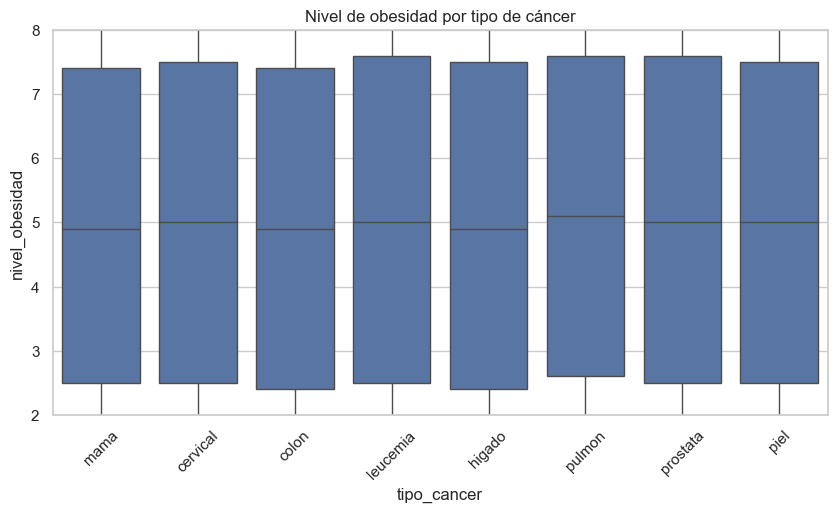

In [289]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=cancer_df, x="tipo_cancer", y="nivel_obesidad")
plt.xticks(rotation=45)
plt.title("Nivel de obesidad por tipo de cáncer")
plt.ylim(2, 8)  # Limita el eje y de 2 a 8
plt.show()

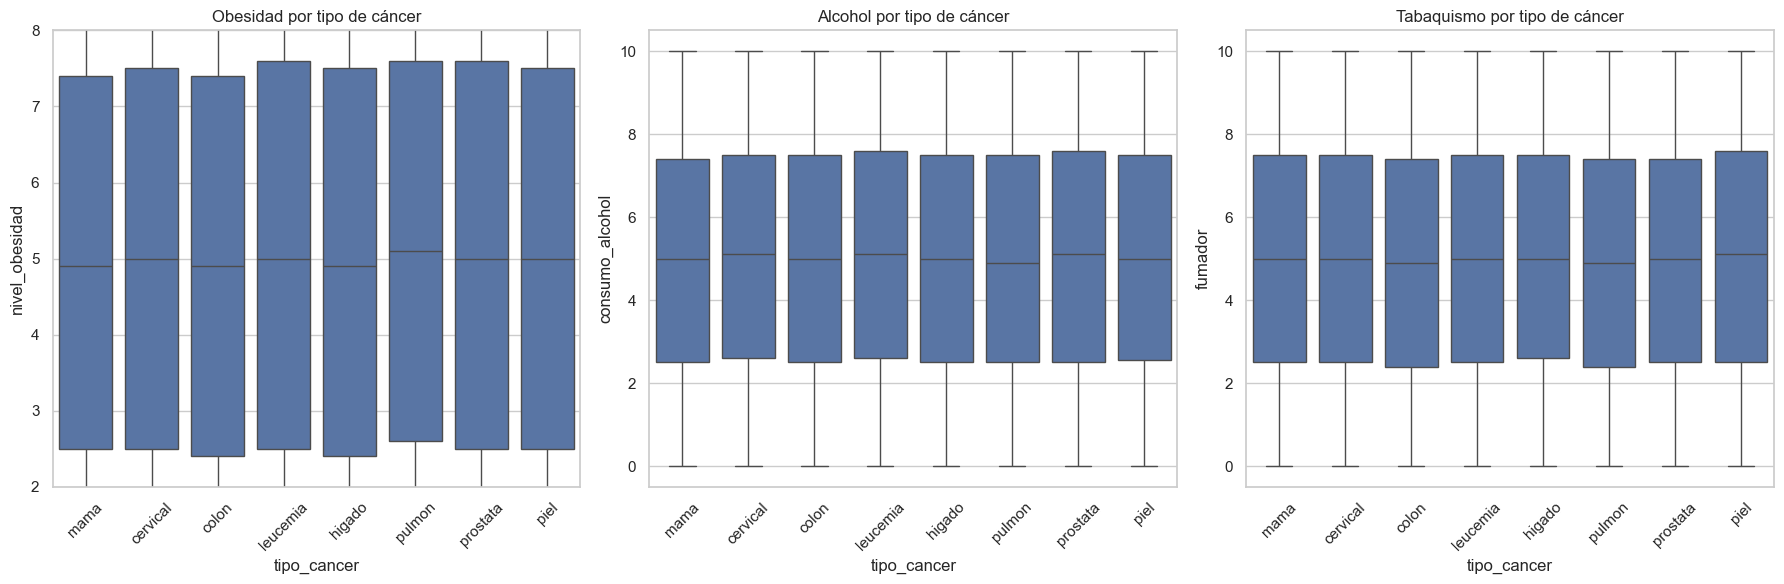

In [294]:
### axes para  hacer subplot, es decir poner varios graficos en una imagen

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharex=False) 

# Boxplot de obesidad
sns.boxplot(data=cancer_df, x="tipo_cancer", y="nivel_obesidad", ax=axes[0])
axes[0].set_title("Obesidad por tipo de cáncer")
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_ylim(2, 8)  # Limita el eje Y

# Boxplot de consumo de alcohol
sns.boxplot(data=cancer_df, x="tipo_cancer", y="consumo_alcohol", ax=axes[1])
axes[1].set_title("Alcohol por tipo de cáncer")
axes[1].tick_params(axis='x', rotation=45)
axes[0].set_ylim(2, 8)  # Limita el eje Y

# Boxplot de tabaquismo
sns.boxplot(data=cancer_df, x="tipo_cancer", y="fumador", ax=axes[2])
axes[2].set_title("Tabaquismo por tipo de cáncer")
axes[2].tick_params(axis='x', rotation=45)
axes[0].set_ylim(2, 8)  # Limita el eje Y

plt.tight_layout()
plt.show()


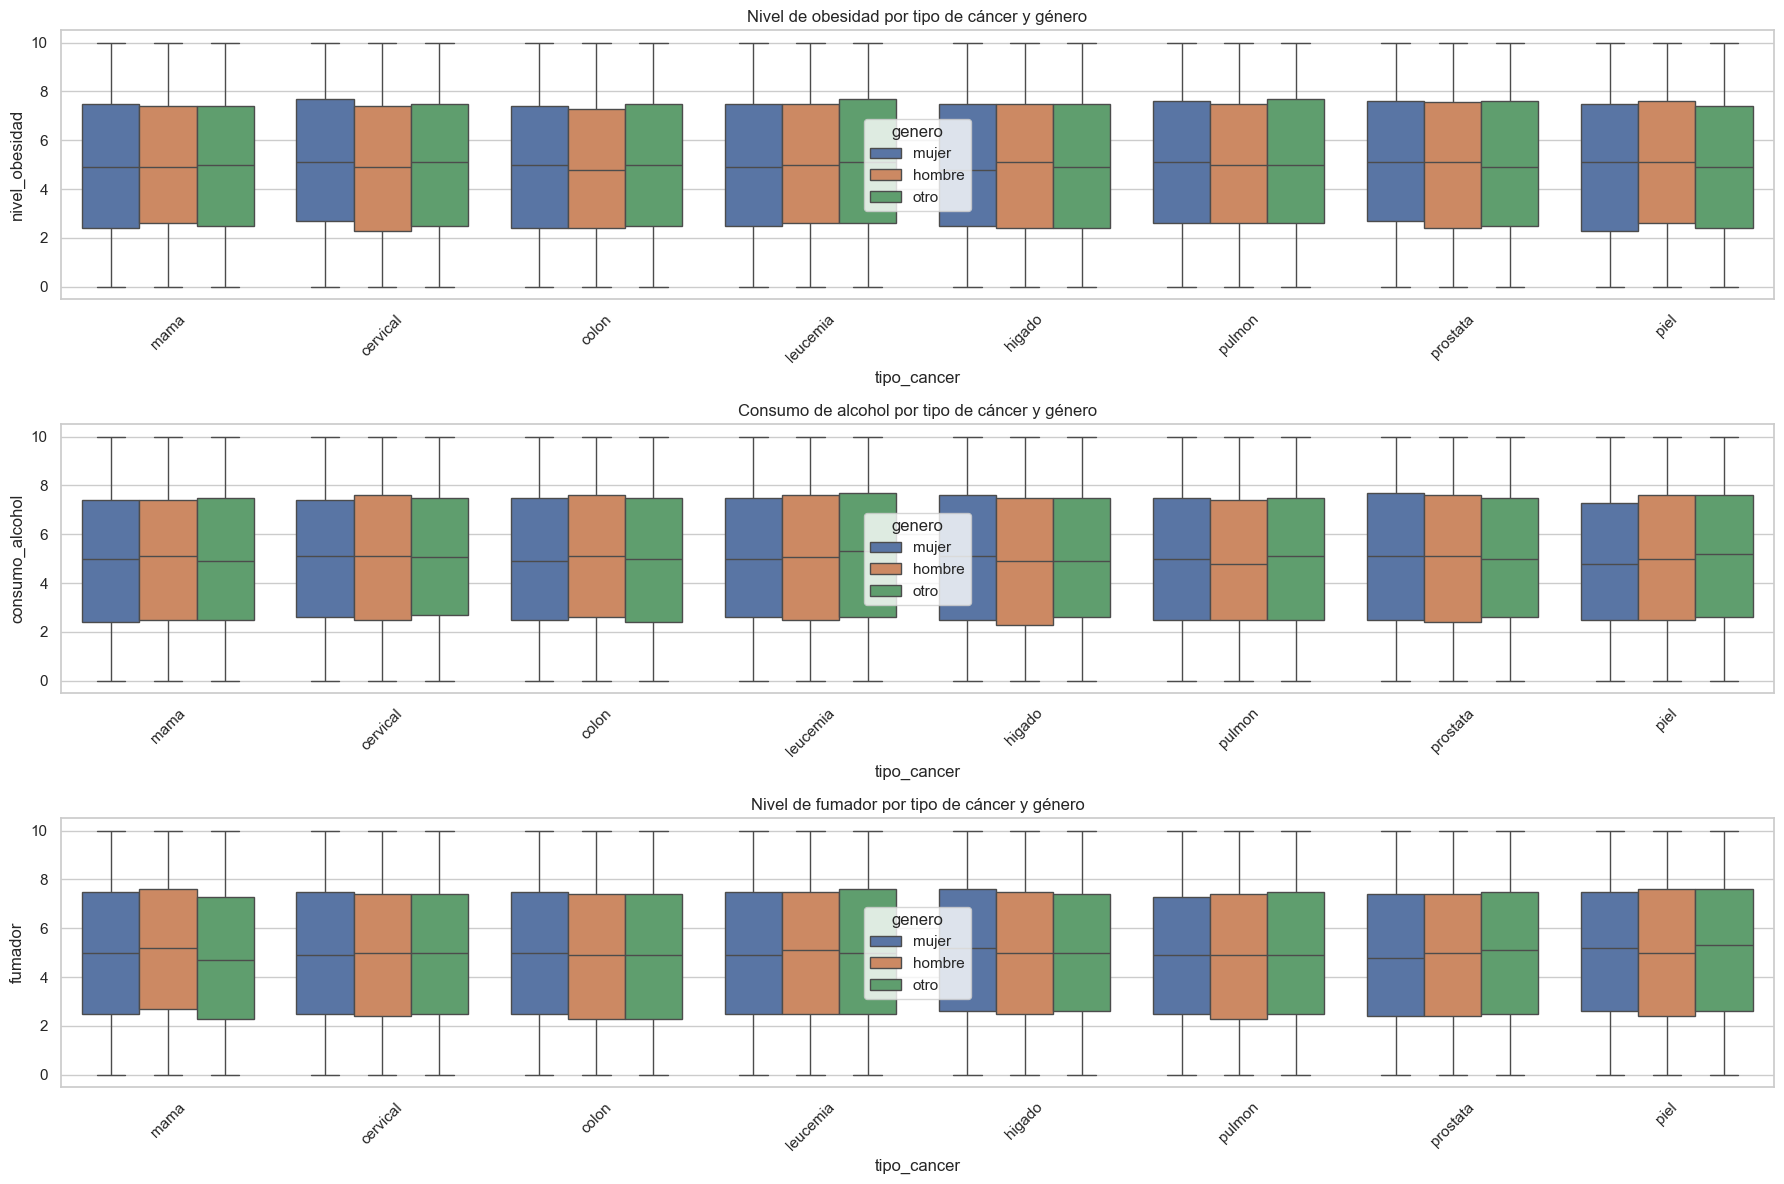

In [286]:

# Ajuste general del estilo
sns.set(style="whitegrid")
plt.figure(figsize=(18, 12))

# Boxplot 1: Obesidad por tipo de cáncer y género
plt.subplot(3, 1, 1)
sns.boxplot(data=cancer_df, x="tipo_cancer", y="nivel_obesidad", hue="genero")
plt.title("Nivel de obesidad por tipo de cáncer y género")
plt.xticks(rotation=45)

# Boxplot 2: Consumo de alcohol por tipo de cáncer y género
plt.subplot(3, 1, 2)
sns.boxplot(data=cancer_df, x="tipo_cancer", y="consumo_alcohol", hue="genero")
plt.title("Consumo de alcohol por tipo de cáncer y género")
plt.xticks(rotation=45)

# Boxplot 3: Nivel de fumador por tipo de cáncer y género
plt.subplot(3, 1, 3)
sns.boxplot(data=cancer_df, x="tipo_cancer", y="fumador", hue="genero")
plt.title("Nivel de fumador por tipo de cáncer y género")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


In [ ]:
!!!
CONCLUSIONES
¿Hay tipos de cáncer que se relacionan con mayores niveles de obesidad o consumo?

¿Hay diferencias marcadas entre hombres y mujeres en alguno de estos factores?


La edad promedio de cancer es  54.42154, incluso la edad promedio por genero ronda esa edad.

